In [1]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt

from skimage.morphology import (
    disk,
    opening,
    closing,
    remove_small_objects,
    remove_small_holes,
)
from rasterio.warp import reproject, Resampling
from matplotlib.colors import ListedColormap

In [42]:
# cluster_tif = "./train_weighted_Orebro_2018/orebro_2020/k8/cluster_map.tif"
cluster_tif = "./k8_h12_d64.tif"
ndwi_tif = "./ground_truth/Orebro lan_mosaic_2020-06-23_ndwi.tif"
# ndwi_tif = "./ground_truth/Orebro lan_mosaic_2018-07-04_ndwi_binary.tif"
# By observation
wetland_clusters = [4] 
NDWI_THRESHOLD = 1.0

For visualizing every single cluster in cluster map

In [43]:
# with rasterio.open(cluster_tif) as src:
#     cluster = src.read(1)

# clusters = np.unique(cluster)

# n = len(clusters)

# fig, axes = plt.subplots(
#     int(np.ceil(n/4)),
#     4,
#     figsize=(16,4*np.ceil(n/4))
# )

# axes = axes.flatten()

# for i, c in enumerate(clusters):
#     axes[i].imshow(cluster == c, cmap="gray")
#     axes[i].set_title(f"Cluster {c}")
#     axes[i].axis("off")

# for i in range(len(clusters), len(axes)):
#     axes[i].axis("off")

# plt.tight_layout()
# plt.show()

This cell is for ndwi visualization

In [44]:
# with rasterio.open(ndwi_tif) as src:
#     ndwi = src.read(1).astype(np.float32)

# ndwi_valid = np.isfinite(ndwi)

# ndwi_water = ndwi_valid & (ndwi == NDWI_THRESHOLD)
# fig = plt.figure(figsize=(5,5), dpi=200)
# plt.imshow(ndwi_water, cmap=ListedColormap(["black", "cyan"]), vmin=0, vmax=1)
# plt.axis("off")
# plt.tight_layout()

In [45]:
with rasterio.open(cluster_tif) as src:
    cluster_map = src.read(1)
    cluster_profile = src.profile.copy()
    cluster_transform = src.transform
    cluster_crs = src.crs
    H, W = cluster_map.shape

valid_cluster = cluster_map >= 0

wetland_candidate = np.isin(cluster_map, wetland_clusters).astype(np.uint8)

with rasterio.open(ndwi_tif) as src:
    ndwi_raw = src.read(1).astype(np.float32)

    same_grid = (
        src.crs == cluster_crs and
        src.transform == cluster_transform and
        src.width == W and
        src.height == H
    )

    if same_grid:
        ndwi = ndwi_raw
    else:
        print("NDWI grid is different. Reprojecting NDWI to cluster grid...")
        ndwi = np.full((H, W), np.nan, dtype=np.float32)

        reproject(
            source=ndwi_raw,
            destination=ndwi,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=cluster_transform,
            dst_crs=cluster_crs,
            dst_width=W,
            dst_height=H,
            resampling=Resampling.bilinear,
            src_nodata=src.nodata,
            dst_nodata=np.nan,
        )

#### Cluster mask post-processing

In [50]:
# Parameters for opening and closing
opening_radius = 3
closing_radius = 3
min_object_size = 200
hole_size = 50

In [51]:
# Only process 'cluster mask'
selem_open = disk(opening_radius)
selem_close = disk(closing_radius)

clean_mask = opening(wetland_candidate, selem_open)
clean_mask = closing(clean_mask, selem_close)

clean_mask = remove_small_objects(clean_mask.astype(bool), max_size=min_object_size)
clean_mask = remove_small_holes(clean_mask.astype(bool), max_size=hole_size)

clean_mask = clean_mask.astype(np.uint8)

#### Calculate metrics

In [52]:
ndwi_valid = np.isfinite(ndwi)

ndwi_water = (ndwi == NDWI_THRESHOLD).astype(np.uint8)

valid = valid_cluster & ndwi_valid

pred = clean_mask[valid].astype(bool)
ref = ndwi_water[valid].astype(bool)

tp = np.logical_and(pred, ref).sum()
fp = np.logical_and(pred, ~ref).sum()
fn = np.logical_and(~pred, ref).sum()
tn = np.logical_and(~pred, ~ref).sum()

precision = tp / (tp + fp + 1e-8)
recall = tp / (tp + fn + 1e-8)
iou = tp / (tp + fp + fn + 1e-8)
f1 = 2 * precision * recall / (precision + recall + 1e-8)

pred_area = pred.sum()
ndwi_area = ref.sum()
overlap_area = tp

print("Selected wetland-like clusters:", wetland_clusters)
print("Valid pixels:", valid.sum())
print("Predicted wetland-like pixels:", pred_area)
print("NDWI water pixels:", ndwi_area)
print("Overlap pixels:", overlap_area)
print(f"Precision against NDWI: {precision:.4f}")
print(f"Recall against NDWI:    {recall:.4f}")
print(f"IoU against NDWI:       {iou:.4f}")
print(f"F1 against NDWI:        {f1:.4f}")


Selected wetland-like clusters: [4]
Valid pixels: 189523380
Predicted wetland-like pixels: 19368580
NDWI water pixels: 20453087
Overlap pixels: 18623147
Precision against NDWI: 0.9615
Recall against NDWI:    0.9105
IoU against NDWI:       0.8785
F1 against NDWI:        0.9353


#### Visualize overlap

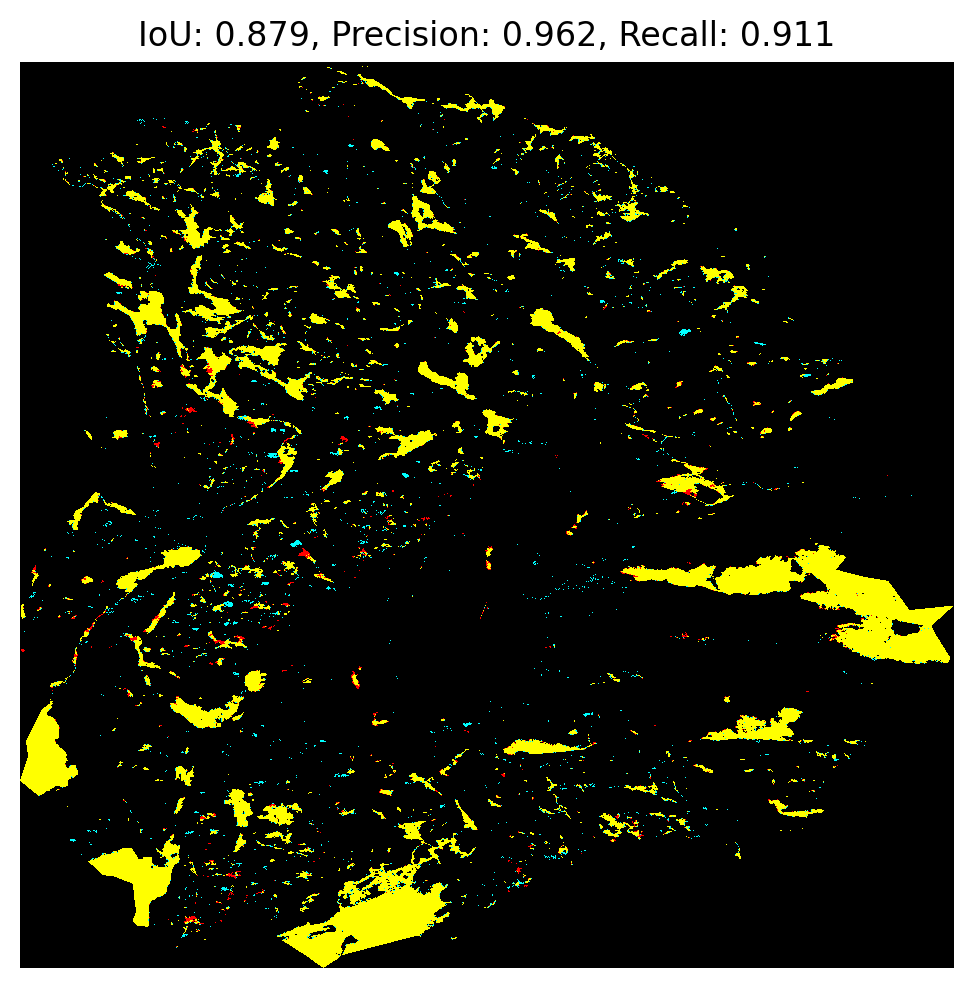

In [53]:
fig = plt.figure(figsize=(5,5), dpi=200)
overlap_map = np.zeros((H, W), dtype=np.uint8)
overlap_map[(clean_mask == 1) & (ndwi_water == 0) & valid] = 1
overlap_map[(clean_mask == 0) & (ndwi_water == 1) & valid] = 2
overlap_map[(clean_mask == 1) & (ndwi_water == 1) & valid] = 3

overlap_cmap = ListedColormap([
    "black",      # 0: neither
    "red",     # 1: selected cluster only
    "cyan",       # 2: NDWI only
    "yellow"        # 3: overlap
])
metrics_text = (
    f"Recall: {recall:.3f}\n"
    f"Precision: {precision:.3f}\n"
    f"IoU: {iou:.3f}"
)
plt.imshow(overlap_map, cmap=overlap_cmap, vmin=0, vmax=3, interpolation="nearest")
plt.title(f"IoU: {iou:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}")
plt.axis("off")

plt.tight_layout()